# Data preparation

## Importing data

In [1]:


from main import LogisticRegressionFS
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('Wisconsin Breast Cancer.csv')
print(df.shape)

(569, 33)


In [2]:
df.head(569)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


## One-hot encoding for the y feature

In [3]:
y = df[['diagnosis' ]]
X = df.drop(['diagnosis','id','Unnamed: 32'], axis=1)
X.head()
#X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=10, test_size=0.2)
y = pd.get_dummies(y, drop_first=True)
y = y.values.astype(float)
#print(y)

## Feature scaling & training and testing data split

In [4]:
#zscore normalization
x_zscore_normalized = (X-X.mean())/X.std()
#x_zscore_normalized.describe()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(x_zscore_normalized,y, random_state=10, test_size=0.2)

# Model training

In [6]:
log_reg = LogisticRegressionFS(learning_rate=0.003, n_iterations=100000)
log_reg.fit(X_train,y_train)

In [7]:
print("Weights of the trained model: ", log_reg.w)

Weights of the trained model:  [[-0.33909488]
 [ 0.47144686]
 [ 0.65885411]
 [ 0.45382149]
 [ 0.55584471]
 [ 0.12956513]
 [-0.43977273]
 [ 0.92487077]
 [ 0.98240674]
 [-0.22517572]
 [-0.34411839]
 [ 1.42618517]
 [-0.10813061]
 [ 0.83437817]
 [ 1.02038243]
 [ 0.28682285]
 [-1.18090371]
 [ 0.10854277]
 [ 0.37579994]
 [-0.9120034 ]
 [-0.91926659]
 [ 1.07842238]
 [ 1.34882686]
 [ 0.91389479]
 [ 1.04171378]
 [ 0.81113435]
 [ 0.01393837]
 [ 1.04883054]
 [ 1.01835152]
 [ 0.77174936]
 [ 0.44917496]]


# Visualization

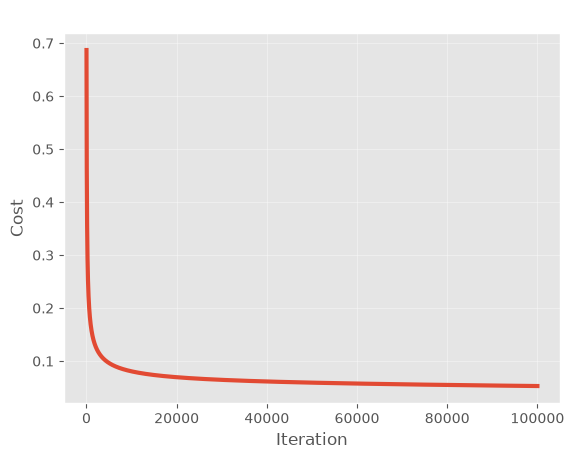

In [8]:
plt.style.use('ggplot')
plt.title('Cost over iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')

plt.plot(log_reg.cost_history, linewidth = 3)
plt.show()

# Printing model's accuracy

In [9]:
# Prediction
y_predict = log_reg.predict(X_test)
#print(y_predict)

In [10]:
print("Model's accuracy:", log_reg.accuracy_test(y_predict, y_test) * 100, "%")

Model's accuracy: 96.49122807017544 %
